# Módulo de Segmentación de Clientes
### Aprendizaje no supervisado — campaña de marketing bancario

**Componente del enfoque híbrido del proyecto.** Agrupa la cartera en segmentos homogéneos para (a) orientar la estrategia comercial por perfil y (b) proporcionar una variable adicional al modelo de clasificación.

---

## 0. Requisitos del entorno

Librerías necesarias para ejecutar este notebook. Descomenta la línea de instalación si trabajas en un entorno nuevo.

In [8]:
# Instalación de dependencias (descomentar si es necesario):
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

import sys, pandas, numpy, matplotlib, seaborn, sklearn, joblib
for nombre, modulo in [("Python", sys), ("pandas", pandas), ("numpy", numpy),
                       ("matplotlib", matplotlib), ("seaborn", seaborn),
                       ("scikit-learn", sklearn), ("joblib", joblib)]:
    version = sys.version.split()[0] if nombre == "Python" else modulo.__version__
    print(f"{nombre:13}: {version}")

Python       : 3.14.3
pandas       : 3.0.1
numpy        : 2.4.3
matplotlib   : 3.10.8
seaborn      : 0.13.2
scikit-learn : 1.8.0
joblib       : 1.5.3


## 1. Objetivo y planteamiento

Se aplica un algoritmo de *clustering* (K-Means) para identificar perfiles de cliente diferenciados. El propósito es doble:

1. **Estratégico:** cuantificar la tasa de conversión por segmento y priorizar los perfiles de mayor propensión.
2. **Operativo:** incorporar la etiqueta de segmento como variable predictora en el modelo de clasificación.

> **Asignación pendiente de definición por el equipo.** La segmentación se sitúa en la frontera entre el análisis exploratorio y el modelado; su desarrollo puede corresponder al perfil de analítica/EDA o al de modelado. Conviene acordarlo antes de la implementación.

**Consideraciones metodológicas (requisitos de validez):**
- El modelo de clustering **se ajusta únicamente sobre el conjunto de entrenamiento** (a diferencia del EDA descriptivo, aquí *se ajusta* un modelo, por lo que la partición es obligatoria).
- **Se excluye la variable objetivo `y`** del proceso (su inclusión introduciría fuga de información).
- **Se excluye `duration`** (fuga de datos, conforme al EDA).

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
NAVY, STEEL, BRICK, GOLD, GREY = "#2A4B7C", "#3C8DAD", "#C1442E", "#B58A2E", "#B8BDC4"
INK = "#1F2733"
plt.rcParams.update({"axes.titleweight": "bold", "axes.titlecolor": INK, "figure.dpi": 110})

## 2. Preparación de los datos

Se realiza la partición `train/test` y se construyen las variables de segmentación a partir de información **disponible con anterioridad al contacto**. El escalado se ajusta sobre el conjunto de entrenamiento.

In [10]:
DATA_PATH = "./data/bank-full.csv"
df = pd.read_csv(DATA_PATH, sep=";")

X = df.drop(columns="y")
y = df["y"]

# Partición estratificada (el clustering se ajusta solo sobre train)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train = X_train.copy()
train["yb"] = (y_train == "yes").astype(int)   # objetivo auxiliar (solo para perfilar, NO para clusterizar)
print(f"Conjunto de entrenamiento: {train.shape[0]:,} registros")

Conjunto de entrenamiento: 36,168 registros


In [11]:
# Variables de segmentación (sin y, sin duration)
train["log_balance"]      = np.sign(train["balance"]) * np.log1p(train["balance"].abs())
train["housing_b"]        = (train["housing"] == "yes").astype(int)
train["loan_b"]           = (train["loan"] == "yes").astype(int)
train["contacted_before"] = (train["pdays"] != -1).astype(int)

feats = ["age", "log_balance", "campaign", "previous", "housing_b", "loan_b", "contacted_before"]

scaler = StandardScaler().fit(train[feats])   # ajuste sobre train
X_scaled = scaler.transform(train[feats])
X_scaled.shape

(36168, 7)

## 3. Selección del número de segmentos

Se evalúa el **coeficiente de silueta** para distintos valores de *k* (sobre una muestra, por eficiencia).

In [12]:
sils = {}
for k in range(2, 8):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    sils[k] = silhouette_score(X_scaled, modelo.labels_, sample_size=5000, random_state=42)
    print(f"k = {k}:  silhouette = {sils[k]:.3f}")

k = 2:  silhouette = 0.315
k = 3:  silhouette = 0.337
k = 4:  silhouette = 0.299
k = 5:  silhouette = 0.314
k = 6:  silhouette = 0.328
k = 7:  silhouette = 0.322


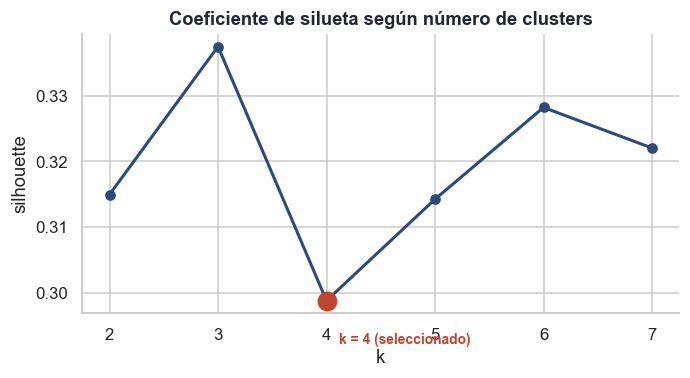

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.3))
ax.plot(list(sils), list(sils.values()), "-o", color=NAVY, lw=2, ms=6)
ax.plot(4, sils[4], "o", color=BRICK, ms=12, zorder=5)
ax.annotate("k = 4 (seleccionado)", (4, sils[4]), textcoords="offset points",
            xytext=(8, -28), color=BRICK, fontweight="bold", fontsize=9)
ax.set_title("Coeficiente de silueta según número de clusters")
ax.set_xlabel("k"); ax.set_ylabel("silhouette")
sns.despine(); plt.show()

**Decisión (con criterio, no automática).** El coeficiente de silueta alcanza su máximo en **k = 3**. No obstante, se selecciona **k = 4**: en segmentación, la **interpretabilidad y accionabilidad** prevalecen sobre la optimización estricta de la métrica. Con k = 4 se diferencia un perfil adicional de valor comercial manteniendo un coeficiente equivalente; k = 5 genera un grupo residual sin interpretación de negocio.

## 4. Ajuste del modelo

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
train["segmento"] = kmeans.labels_
train["segmento"].value_counts().sort_index()

segmento
0     5152
1    11437
2     6359
3    13220
Name: count, dtype: int64

## 5. Caracterización de los segmentos

In [15]:
perfil = train.groupby("segmento").agg(
    n               = ("yb", "size"),
    conversion_pct  = ("yb", lambda s: round(s.mean() * 100, 1)),
    edad_media      = ("age", "mean"),
    saldo_mediano   = ("balance", "median"),
    hipoteca_pct    = ("housing_b", lambda s: round(s.mean() * 100)),
    prestamo_pct    = ("loan_b", lambda s: round(s.mean() * 100)),
    contacto_previo = ("contacted_before", lambda s: round(s.mean() * 100)),
).round(1)
perfil["pct_cartera"] = (perfil["n"] / len(train) * 100).round(1)
perfil.sort_values("conversion_pct", ascending=False)

,n,conversion_pct,edad_media,saldo_mediano,hipoteca_pct,prestamo_pct,contacto_previo,pct_cartera
segmento,,,,,,,,
2,6359,23.3,40.9,650.0,62,10,100,17.6
1,11437,13.5,43.2,530.0,0,0,0,31.6
3,13220,6.7,39.1,420.0,100,0,0,36.6
0,5152,6.3,40.4,217.0,59,100,4,14.2


In [16]:
# Etiquetas descriptivas de cada segmento (según su perfil)
nombres = {}
for s in perfil.index:
    sub = train[train["segmento"] == s]
    if sub["contacted_before"].mean() > 0.5:
        nombres[s] = "Contactados previamente"
    elif sub["loan_b"].mean() > 0.5:
        nombres[s] = "Con préstamo · saldo reducido"
    elif sub["housing_b"].mean() > 0.5:
        nombres[s] = "Con hipoteca"
    else:
        nombres[s] = "Sin cargas financieras"
nombres

{0: 'Con préstamo · saldo reducido',
 1: 'Sin cargas financieras',
 2: 'Contactados previamente',
 3: 'Con hipoteca'}

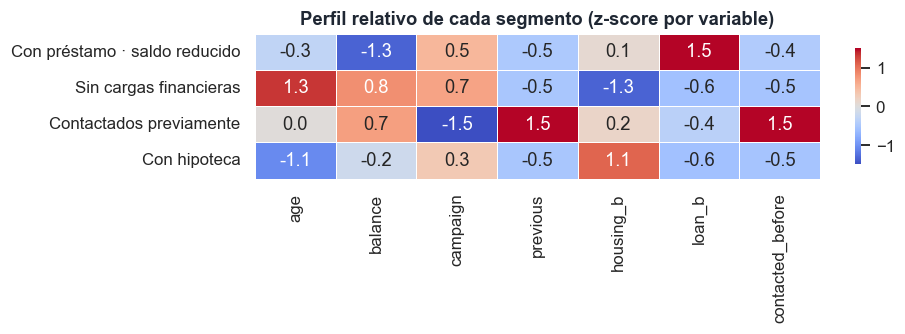

In [17]:
# Perfil relativo (valores estandarizados por variable)
cols = ["age", "balance", "campaign", "previous", "housing_b", "loan_b", "contacted_before"]
medias = train.groupby("segmento")[cols].mean()
z = (medias - medias.mean()) / medias.std()
z.index = [nombres[s] for s in z.index]

plt.figure(figsize=(9, 3.2))
sns.heatmap(z, annot=True, fmt=".1f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Perfil relativo de cada segmento (z-score por variable)")
plt.ylabel(""); plt.tight_layout(); plt.show()

## 6. Resultados e interpretación de negocio

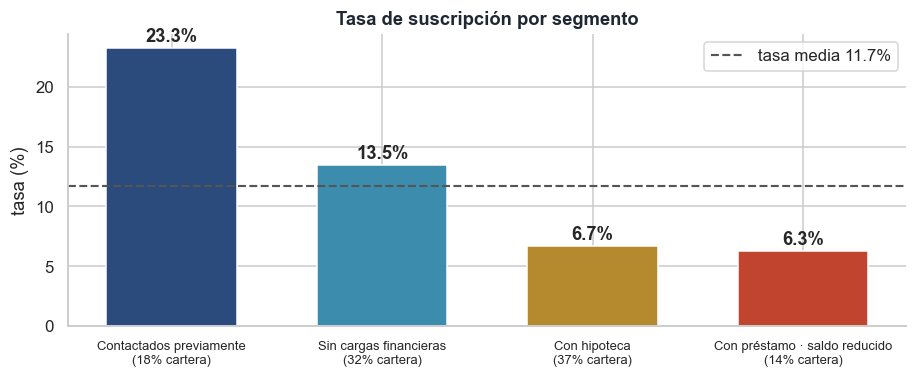

In [18]:
base = train["yb"].mean() * 100
orden = perfil.sort_values("conversion_pct", ascending=False).index
colores = [NAVY, STEEL, GOLD, BRICK]

fig, ax = plt.subplots(figsize=(8.5, 3.6))
etiquetas = [f"{nombres[s]}\n({perfil.loc[s,'pct_cartera']:.0f}% cartera)" for s in orden]
valores   = [perfil.loc[s, "conversion_pct"] for s in orden]
ax.bar(range(len(orden)), valores, color=colores, width=0.62)
ax.axhline(base, color="#555", ls="--", lw=1.4, label=f"tasa media {base:.1f}%")
for i, v in enumerate(valores):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_xticks(range(len(orden))); ax.set_xticklabels(etiquetas, fontsize=8.5)
ax.set_title("Tasa de suscripción por segmento"); ax.set_ylabel("tasa (%)")
ax.legend(); sns.despine(); plt.tight_layout(); plt.show()

**Interpretación:**

- El segmento **"Contactados previamente"** presenta la mayor tasa de suscripción (~23 %, aproximadamente el doble de la media), en línea con el hallazgo del EDA sobre `poutcome`.
- El segmento **"Sin cargas financieras"** supera la media (mayor capacidad de ahorro).
- Los segmentos **"Con hipoteca"** y **"Con préstamo · saldo reducido"** registran tasas inferiores a la media.
- La conversión varía **de ~23 % a ~6 %** según el segmento: existe separación real, lo que permite **despriorizar** aproximadamente la mitad de la cartera (los dos segmentos de menor conversión) y concentrar el esfuerzo comercial en los perfiles de mayor propensión.

## 7. Integración en el pipeline y reproducibilidad

La etiqueta de segmento se incorpora como **variable predictora adicional** en el preprocesado. Dado que la asignación de segmento forma parte de la inferencia, es necesario **serializar el modelo de clustering y el escalador** junto con el clasificador final: en producción, cada nuevo registro se asigna primero a un segmento y después se puntúa.

In [19]:
import joblib, os

# En el repositorio, la ruta recomendada es src/models/
os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler_segmentacion.pkl")
joblib.dump(kmeans, "models/kmeans_segmentacion.pkl")
print("Artefactos guardados: scaler_segmentacion.pkl, kmeans_segmentacion.pkl")

Artefactos guardados: scaler_segmentacion.pkl, kmeans_segmentacion.pkl


In [20]:
# Asignación de segmento a nuevos datos (ejemplo con el conjunto de test)
def asignar_segmento(datos, scaler, kmeans):
    d = datos.copy()
    d["log_balance"]      = np.sign(d["balance"]) * np.log1p(d["balance"].abs())
    d["housing_b"]        = (d["housing"] == "yes").astype(int)
    d["loan_b"]           = (d["loan"] == "yes").astype(int)
    d["contacted_before"] = (d["pdays"] != -1).astype(int)
    return kmeans.predict(scaler.transform(d[feats]))

segmentos_test = asignar_segmento(X_test, scaler, kmeans)
pd.Series(segmentos_test).value_counts().sort_index()

0    1248
1    2925
2    1619
3    3251
Name: count, dtype: int64

## 8. Conclusiones

1. La segmentación identifica **4 perfiles de cliente** con tasas de conversión claramente diferenciadas (~23 % a ~6 %).
2. El perfil de mayor propensión corresponde a **clientes con interacción en campañas previas**, coherente con el análisis exploratorio.
3. La separación observada permite una **priorización comercial** por perfil, complementaria al *scoring* individual del clasificador.
4. Para su uso en producción se serializan el **escalador** y el **modelo de clustering**, garantizando la reproducibilidad de la asignación de segmentos.

---
*Módulo desarrollado sobre el conjunto de entrenamiento, sin uso de la variable objetivo ni de `duration`. Componente del enfoque híbrido (segmentación + clasificación).*